<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Model Training - Decision Tree Classifier (Student Performance)</b></center>
<pre>

# import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Import student_performance.xlsx dataset

In [2]:
df = pd.read_excel('student_performance.xlsx')
df

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,23,Male,3rd Year,3.0,0,178,Gemini,NaN,6,...,5,8.1,19.2,8.3,1.9,1.0,10,49.7,1,Low
7996,7997,21,Other,1st Year,3.3,0,63,Claude,Exam Prep,10,...,6,5.7,3.0,5.0,1.3,2.9,5,58.4,1,Medium
7997,7998,24,Male,3rd Year,1.6,0,113,ChatGPT,Coding,5,...,6,4.5,-18.0,5.0,3.5,0.1,9,69.1,1,Medium
7998,7999,22,Female,2nd Year,5.5,0,21,Copilot,Coding,5,...,8,3.4,-19.1,4.7,5.9,0.4,7,49.2,1,Low


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       8000 non-null   int64  
 1   age                              8000 non-null   int64  
 2   gender                           8000 non-null   object 
 3   grade_level                      8000 non-null   object 
 4   study_hours_per_day              8000 non-null   float64
 5   uses_ai                          8000 non-null   int64  
 6   ai_usage_time_minutes            8000 non-null   int64  
 7   ai_tools_used                    6638 non-null   object 
 8   ai_usage_purpose                 6654 non-null   object 
 9   ai_dependency_score              8000 non-null   int64  
 10  ai_generated_content_percentage  8000 non-null   int64  
 11  ai_prompts_per_week              8000 non-null   int64  
 12  ai_ethics_score     

# Check the distribution of the target

In [4]:
print(df['passed'].value_counts())

passed
1    7114
0     886
Name: count, dtype: int64


# Handle Data Types and Clean Non-Numeric Values in Numeric Columns

In [5]:
# Convert study_consistency_index to numeric, replacing non-numeric characters with NaN
df['study_consistency_index'] = pd.to_numeric(df['study_consistency_index'], errors='coerce')
df.head()

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


# Check for missing values

In [6]:
df.isnull().sum()

student_id                            0
age                                   0
gender                                0
grade_level                           0
study_hours_per_day                   0
uses_ai                               0
ai_usage_time_minutes                 0
ai_tools_used                      1362
ai_usage_purpose                   1346
ai_dependency_score                   0
ai_generated_content_percentage       0
ai_prompts_per_week                   0
ai_ethics_score                       0
last_exam_score                       0
assignment_scores_avg                 0
attendance_percentage                 0
concept_understanding_score           0
study_consistency_index               1
improvement_rate                      0
sleep_hours                           0
social_media_hours                    0
tutoring_hours                        0
class_participation_score             0
final_score                           0
passed                                0


# Fill missing values (Median for numerical, 'None' for categorical)

In [7]:
# Fill numeric missing values with median
df['study_consistency_index'] = df['study_consistency_index'].fillna(df['study_consistency_index'].median())

# Fill categorical missing values
df['ai_tools_used'] = df['ai_tools_used'].fillna('None')
df['ai_usage_purpose'] = df['ai_usage_purpose'].fillna('None')

df.head()

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,None,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,None,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


In [8]:
df.isnull().sum()

student_id                         0
age                                0
gender                             0
grade_level                        0
study_hours_per_day                0
uses_ai                            0
ai_usage_time_minutes              0
ai_tools_used                      0
ai_usage_purpose                   0
ai_dependency_score                0
ai_generated_content_percentage    0
ai_prompts_per_week                0
ai_ethics_score                    0
last_exam_score                    0
assignment_scores_avg              0
attendance_percentage              0
concept_understanding_score        0
study_consistency_index            0
improvement_rate                   0
sleep_hours                        0
social_media_hours                 0
tutoring_hours                     0
class_participation_score          0
final_score                        0
passed                             0
performance_category               0
dtype: int64

# Visualize Distributions

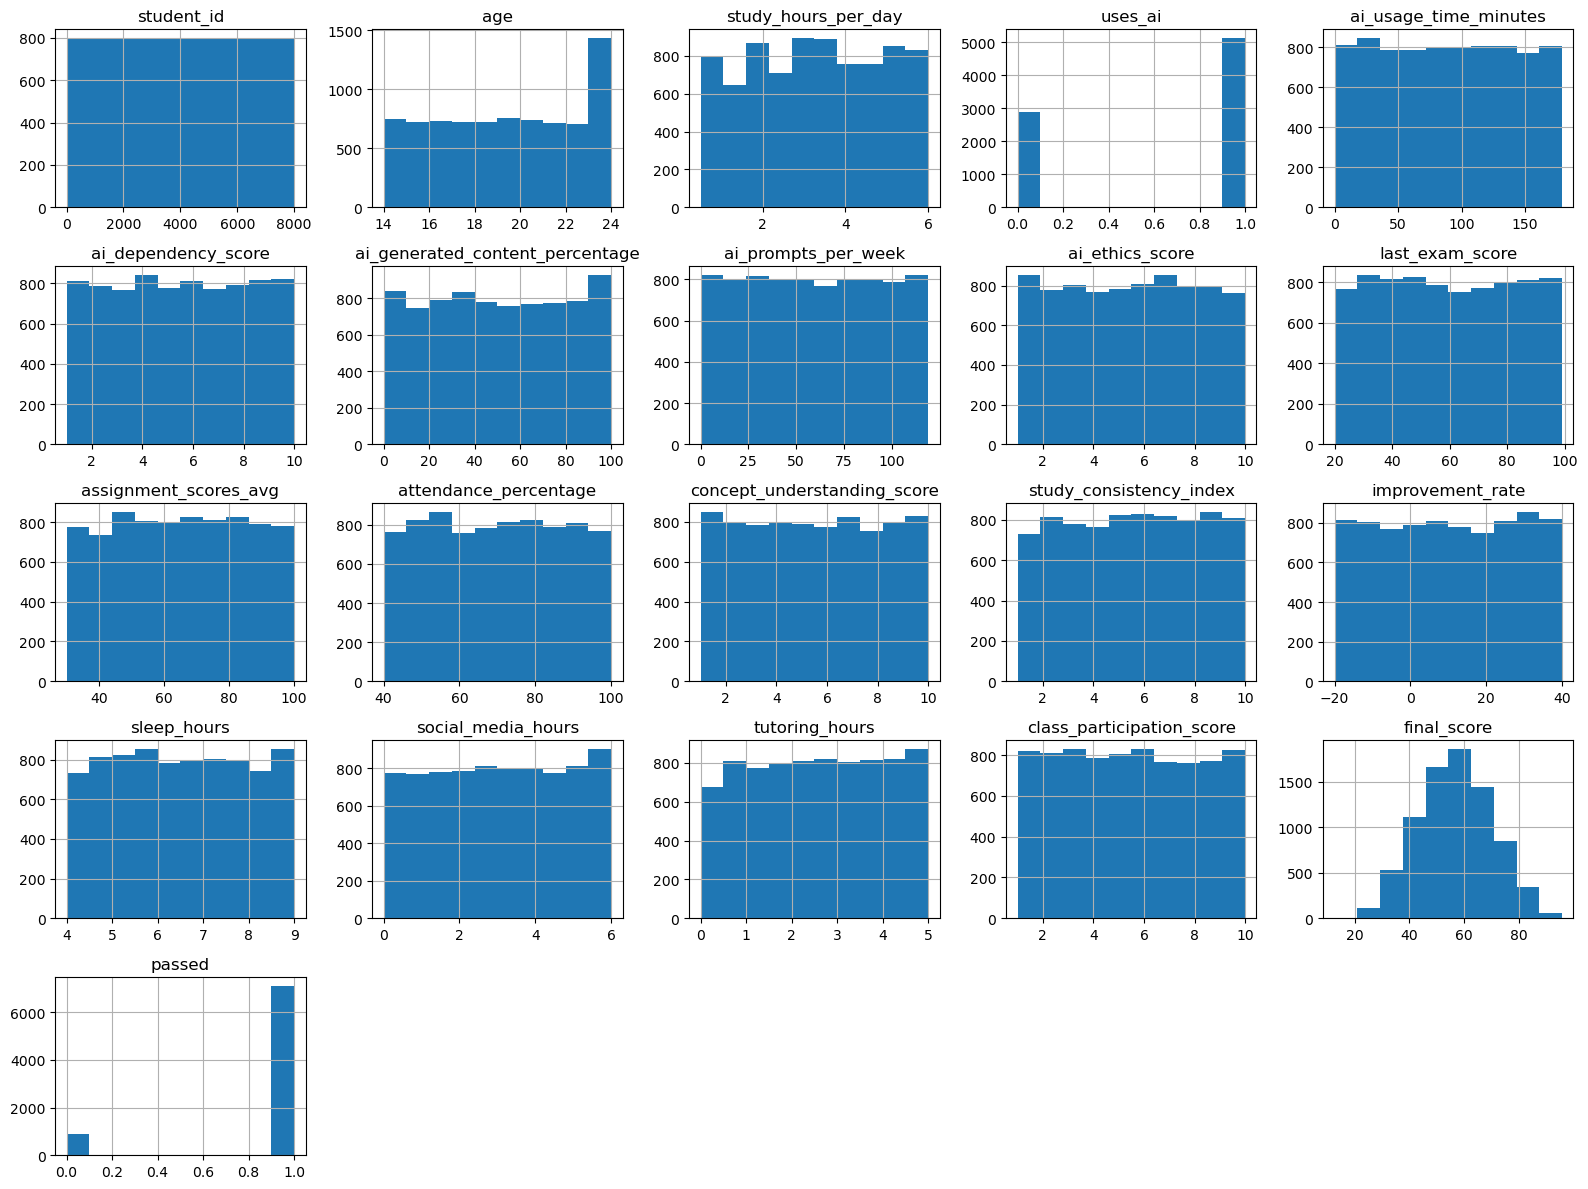

In [9]:
df.hist(figsize=(16, 12))
plt.tight_layout()
plt.show()

# Convert Categorical data into integer code

In [10]:
df['passed'].unique()

array([0, 1])

In [11]:
cat_cols = ['gender', 'grade_level', 'ai_tools_used', 'ai_usage_purpose']
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,0,3,2.5,1,170,5,2,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,1,2,3.4,1,123,5,5,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,1,5,0.8,0,35,3,1,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,0,2,4.4,0,45,1,5,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,2,5,3.5,1,21,1,0,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


In [12]:
df['passed']

0       0
1       1
2       1
3       1
4       1
       ..
7995    1
7996    1
7997    1
7998    1
7999    1
Name: passed, Length: 8000, dtype: int64

# Divide the data into input and output

In [13]:
# Axis = 1 means drop column, axis = 0 means drop row
# Drop student_id (id column) and direct score outputs (final_score, performance_category) along with target 'passed'
x = df.drop(columns=['student_id', 'final_score', 'performance_category', 'passed'])
y = df['passed']

# shape gives the number of rows and columns in the dataset
print(x.shape)
# y.shape gives the number of rows and columns in the dataset
print(y.shape)

(8000, 22)
(8000,)


# Splitting the dataset into the Training set and Test set

In [14]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
X_train.shape

(6400, 22)

In [16]:
X_test.shape

(1600, 22)

# Create Model

In [17]:
from sklearn.tree import DecisionTreeClassifier

In [18]:
model = DecisionTreeClassifier()

# Fitting DecisionTreeClassifier on dataset across various depths

In [19]:
for depth in range(1, 11):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Depth: {depth}, TrainingAccuracy: {model.score(X_train, y_train)}, "
          f"TestingAccuracy: {model.score(X_test, y_test)}")

Depth: 1, TrainingAccuracy: 0.88875, TestingAccuracy: 0.89125
Depth: 2, TrainingAccuracy: 0.89703125, TestingAccuracy: 0.88625
Depth: 3, TrainingAccuracy: 0.92484375, TestingAccuracy: 0.920625
Depth: 4, TrainingAccuracy: 0.92515625, TestingAccuracy: 0.92375
Depth: 5, TrainingAccuracy: 0.9353125, TestingAccuracy: 0.9225


Depth: 6, TrainingAccuracy: 0.94625, TestingAccuracy: 0.92875
Depth: 7, TrainingAccuracy: 0.95921875, TestingAccuracy: 0.913125


Depth: 8, TrainingAccuracy: 0.975, TestingAccuracy: 0.913125
Depth: 9, TrainingAccuracy: 0.985625, TestingAccuracy: 0.90875
Depth: 10, TrainingAccuracy: 0.99328125, TestingAccuracy: 0.90875


# Display Decision Tree

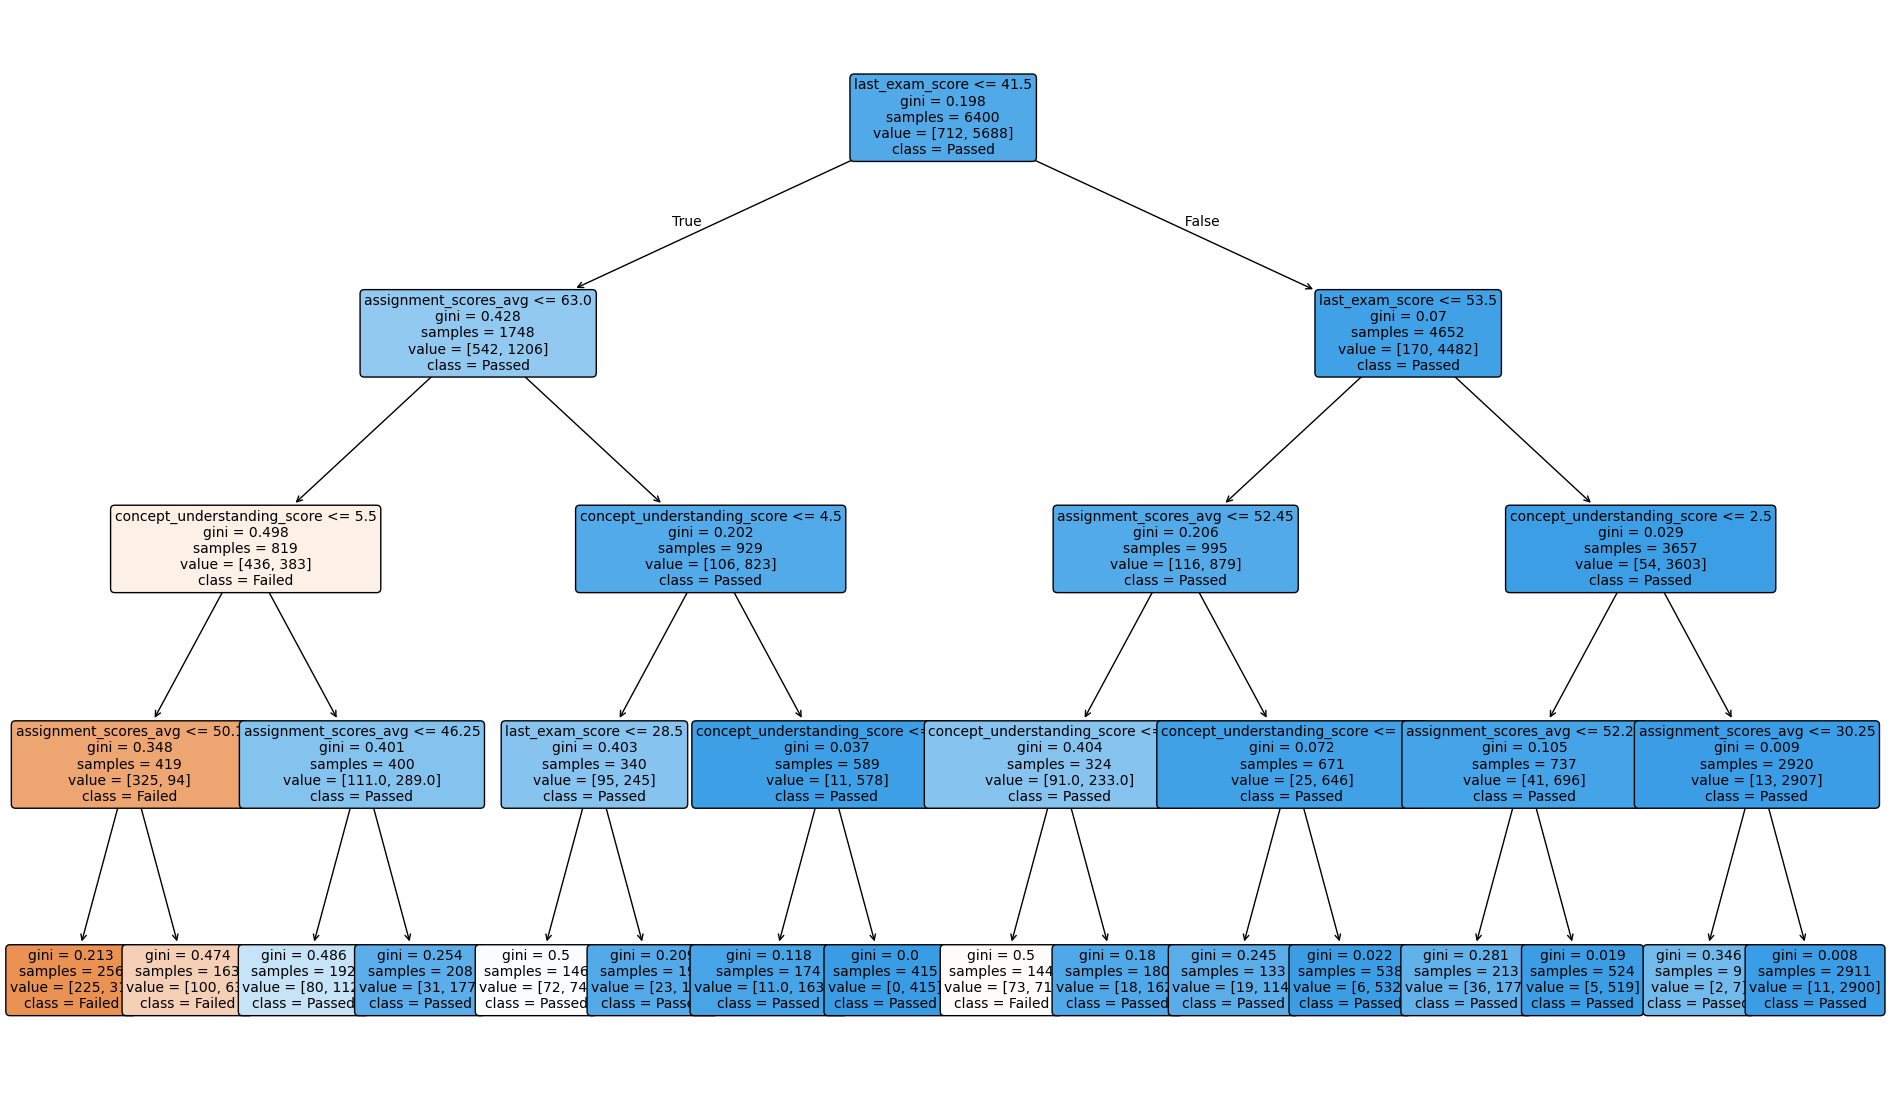

In [20]:
# Final model with optimal depth
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

plt.figure(figsize=(24, 14))
plot_tree(model, filled=True, feature_names=list(x.columns), class_names=['Failed', 'Passed'], rounded=True, fontsize=10)
plt.show()

# Predict the x_test

In [21]:
y_pred = model.predict(X_test)
print(y_pred)

[0 1 1 ... 1 1 1]


# Display Training Accuracy

In [22]:
TrainingAccuracy = model.score(X_train, y_train)
TrainingAccuracy

0.92515625

# Display Test Accuracy

In [23]:
testAccuracy = model.score(X_test, y_test)
testAccuracy

0.92375

# Confusion Matrix

In [24]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 102   72]
 [  50 1376]]


# Display Confusion Matrix Plot

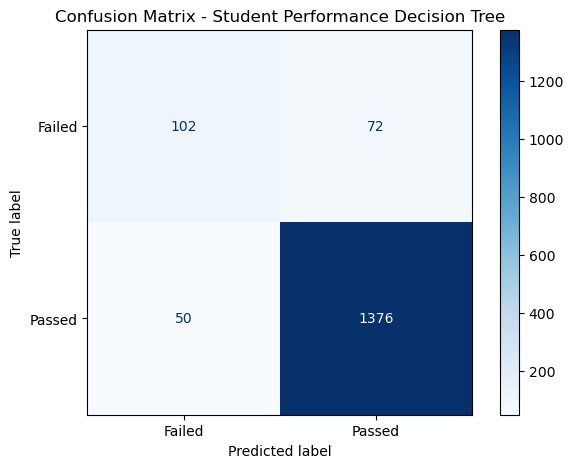

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failed', 'Passed'])
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
plt.title('Confusion Matrix - Student Performance Decision Tree')
plt.show()

# Classification Report

In [26]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Failed', 'Passed']))

Classification Report:

              precision    recall  f1-score   support

      Failed       0.67      0.59      0.63       174
      Passed       0.95      0.96      0.96      1426

    accuracy                           0.92      1600
   macro avg       0.81      0.78      0.79      1600
weighted avg       0.92      0.92      0.92      1600

